In [38]:
import scanpy as sc

adata = sc.read("/data1/r20user3/shared_project/Hist2Cell/data/human_lung_cell2location/sp.X_norm5e4_log1p.h5ad")
center_col = adata.obs.array_col
center_row = adata.obs.array_row
center_col

spot_id
WSA_LngSP8759311_AAACAAGTATCTCCCA-1     102
WSA_LngSP8759311_AAACAGAGCGACTCCT-1      94
WSA_LngSP8759311_AAACATTTCCCGGATT-1      97
WSA_LngSP8759311_AAACCCGAACGAAATC-1     115
WSA_LngSP8759311_AAACCGTTCGTCCAGG-1      42
                                       ... 
WSA_LngSP10193348_TTGTGTATGCCACCAA-1     60
WSA_LngSP10193348_TTGTGTTTCCCGAAAG-1     59
WSA_LngSP10193348_TTGTTAGCAAATTCGA-1     42
WSA_LngSP10193348_TTGTTGTGTGTCAAGA-1     77
WSA_LngSP10193348_TTGTTTCACATCCAGG-1     42
Name: array_col, Length: 20770, dtype: int64

In [39]:
import os
import pandas as pd

slide = "WSA_LngSP8759311"

spot_df = pd.read_csv(os.path.join("/data1/r20user3/shared_project/Hist2Cell/data/human_lung_cell2location", slide, "spots.csv"), index_col=0)
spot_df['X_int'] = center_col.loc[spot_df.index]
spot_df['Y_int'] = center_row.loc[spot_df.index]
cell_abundance_df = pd.read_csv(os.path.join("/data1/r20user3/shared_project/Hist2Cell/data/human_lung_cell2location", slide, "cell_ratio.csv"), index_col=0)

In [40]:
spot_df

,X,Y,X_int,Y_int
spot_id,,,,
WSA_LngSP8759311_AAACAAGTATCTCCCA-1,12643,10675,102,50
WSA_LngSP8759311_AAACAGAGCGACTCCT-1,11770,3805,94,14
WSA_LngSP8759311_AAACATTTCCCGGATT-1,12093,12773,97,61
WSA_LngSP8759311_AAACCCGAACGAAATC-1,14069,9721,115,45
WSA_LngSP8759311_AAACCGTTCGTCCAGG-1,6063,11052,42,52
...,...,...,...,...
WSA_LngSP8759311_TTGTGTTTCCCGAAAG-1,7928,10862,59,51
WSA_LngSP8759311_TTGTTAGCAAATTCGA-1,6067,5328,42,22
WSA_LngSP8759311_TTGTTCAGTGTGCTAC-1,8479,5711,64,24


In [41]:
from hmac import new


for index, row in spot_df.iterrows():
    x_int = int(row['X_int'])
    y_int = int(row['Y_int'])
    
    if not spot_df[(spot_df['X_int'] == (x_int-2))&(spot_df['Y_int'] == (y_int))].empty:
        new_x_int = x_int - 1
        new_y_int = y_int
        neighbor_row = spot_df[(spot_df['X_int'] == (x_int-2))&(spot_df['Y_int'] == (y_int))]
        if str(new_x_int) + "x" + str(new_y_int) not in spot_df.index:
            new_x_pixel = (row['X']+neighbor_row.iloc[0]['X'])/2
            new_y_pixel = (row['Y']+neighbor_row.iloc[0]['Y'])/2
            spot_df.loc[str(new_x_int) + "x" + str(new_y_int)] = {"X": new_x_pixel, "Y": new_y_pixel, "X_int": new_x_int, "Y_int": new_y_int}
    
    if not spot_df[(spot_df['X_int'] == (x_int+2))&(spot_df['Y_int'] == (y_int))].empty:
        new_x_int = x_int + 1
        new_y_int = y_int
        neighbor_row = spot_df[(spot_df['X_int'] == (x_int+2))&(spot_df['Y_int'] == (y_int))]
        if str(new_x_int) + "x" + str(new_y_int) not in spot_df.index:
            new_x_pixel = (row['X']+neighbor_row.iloc[0]['X'])/2
            new_y_pixel = (row['Y']+neighbor_row.iloc[0]['Y'])/2
            spot_df.loc[str(new_x_int) + "x" + str(new_y_int)] = {"X": new_x_pixel, "Y": new_y_pixel, "X_int": new_x_int, "Y_int": new_y_int}
            
    if not spot_df[(spot_df['X_int'] == (x_int-1))&(spot_df['Y_int'] == (y_int-1))].empty:
        new_x_int = x_int - 0.5
        new_y_int = y_int - 0.5
        neighbor_row = spot_df[(spot_df['X_int'] == (x_int-1))&(spot_df['Y_int'] == (y_int-1))]
        if str(new_x_int) + "x" + str(new_y_int) not in spot_df.index:
            new_x_pixel = (row['X']+neighbor_row.iloc[0]['X'])/2
            new_y_pixel = (row['Y']+neighbor_row.iloc[0]['Y'])/2
            spot_df.loc[str(new_x_int) + "x" + str(new_y_int)] = {"X": new_x_pixel, "Y": new_y_pixel, "X_int": new_x_int, "Y_int": new_y_int}
    
    if not spot_df[(spot_df['X_int'] == (x_int+1))&(spot_df['Y_int'] == (y_int-1))].empty:
        new_x_int = x_int + 0.5
        new_y_int = y_int - 0.5
        neighbor_row = spot_df[(spot_df['X_int'] == (x_int+1))&(spot_df['Y_int'] == (y_int-1))]
        if str(new_x_int) + "x" + str(new_y_int) not in spot_df.index:
            new_x_pixel = (row['X']+neighbor_row.iloc[0]['X'])/2
            new_y_pixel = (row['Y']+neighbor_row.iloc[0]['Y'])/2
            spot_df.loc[str(new_x_int) + "x" + str(new_y_int)] = {"X": new_x_pixel, "Y": new_y_pixel, "X_int": new_x_int, "Y_int": new_y_int}
    
    if not spot_df[(spot_df['X_int'] == (x_int-1))&(spot_df['Y_int'] == (y_int+1))].empty:
        new_x_int = x_int - 0.5
        new_y_int = y_int + 0.5
        neighbor_row = spot_df[(spot_df['X_int'] == (x_int-1))&(spot_df['Y_int'] == (y_int+1))]
        if str(new_x_int) + "x" + str(new_y_int) not in spot_df.index:
            new_x_pixel = (row['X']+neighbor_row.iloc[0]['X'])/2
            new_y_pixel = (row['Y']+neighbor_row.iloc[0]['Y'])/2
            spot_df.loc[str(new_x_int) + "x" + str(new_y_int)] = {"X": new_x_pixel, "Y": new_y_pixel, "X_int": new_x_int, "Y_int": new_y_int}
    
    if not spot_df[(spot_df['X_int'] == (x_int+1))&(spot_df['Y_int'] == (y_int+1))].empty:
        new_x_int = x_int + 0.5
        new_y_int = y_int + 0.5
        neighbor_row = spot_df[(spot_df['X_int'] == (x_int+1))&(spot_df['Y_int'] == (y_int+1))]
        if str(new_x_int) + "x" + str(new_y_int) not in spot_df.index:
            new_x_pixel = (row['X']+neighbor_row.iloc[0]['X'])/2
            new_y_pixel = (row['Y']+neighbor_row.iloc[0]['Y'])/2
            spot_df.loc[str(new_x_int) + "x" + str(new_y_int)] = {"X": new_x_pixel, "Y": new_y_pixel, "X_int": new_x_int, "Y_int": new_y_int}
            

In [42]:
spot_df

,X,Y,X_int,Y_int
spot_id,,,,
WSA_LngSP8759311_AAACAAGTATCTCCCA-1,12643.0,10675.0,102.0,50.0
WSA_LngSP8759311_AAACAGAGCGACTCCT-1,11770.0,3805.0,94.0,14.0
WSA_LngSP8759311_AAACATTTCCCGGATT-1,12093.0,12773.0,97.0,61.0
WSA_LngSP8759311_AAACCCGAACGAAATC-1,14069.0,9721.0,115.0,45.0
WSA_LngSP8759311_AAACCGTTCGTCCAGG-1,6063.0,11052.0,42.0,52.0
...,...,...,...,...
60.5x17.5,8096.0,4470.5,60.5,17.5
36x23,5409.0,5518.0,36.0,23.0
86.5x55.5,10942.5,11723.0,86.5,55.5


In [43]:
spot_df.to_csv(os.path.join("/data1/r20user3/shared_project/Hist2Cell/data/human_lung_cell2location", slide, "2x_spots.csv"))

In [45]:
spot_df = pd.read_csv(os.path.join("/data1/r20user3/shared_project/Hist2Cell/data/human_lung_cell2location", slide, "spots.csv"), index_col=0)
spot_df_2x = pd.read_csv(os.path.join("/data1/r20user3/shared_project/Hist2Cell/data/human_lung_cell2location", slide, "2x_spots.csv"), index_col=0)

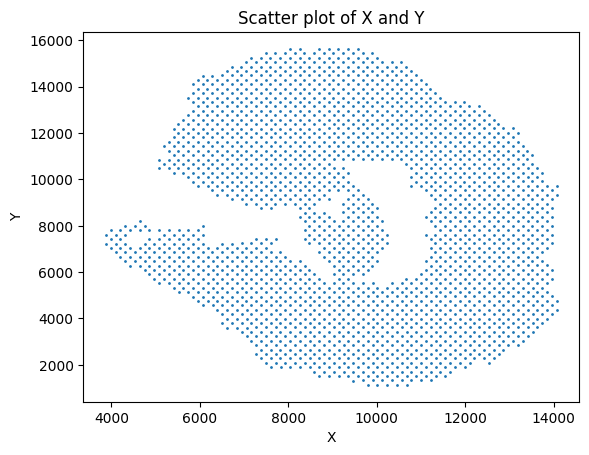

In [49]:
import pandas as pd
import matplotlib.pyplot as plt

plt.scatter(spot_df['X'], spot_df['Y'], s=1)

# 为图表添加标题和轴标签
plt.title('Scatter plot of X and Y')
plt.xlabel('X')
plt.ylabel('Y')

# 显示图表
plt.show()

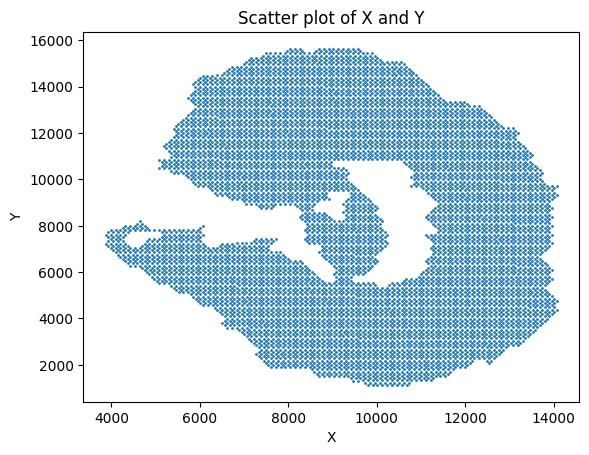

In [50]:
plt.scatter(spot_df_2x['X'], spot_df_2x['Y'], s=1)

# 为图表添加标题和轴标签
plt.title('Scatter plot of X and Y')
plt.xlabel('X')
plt.ylabel('Y')

# 显示图表
plt.show()

In [59]:
from glob import glob
from tqdm import tqdm

slide_list = glob("/data1/r20user3/shared_project/Hist2Cell/data/human_lung_cell2location/W*")
for slide_path in tqdm(slide_list):
    slide = slide_path.split("/")[-1]
    
    spot_df = pd.read_csv(os.path.join("/data1/r20user3/shared_project/Hist2Cell/data/human_lung_cell2location", slide, "spots.csv"), index_col=0)
    spot_df['X_int'] = center_col.loc[spot_df.index]
    spot_df['Y_int'] = center_row.loc[spot_df.index]
    
    for index, row in spot_df.iterrows():
        x_int = int(row['X_int'])
        y_int = int(row['Y_int'])
        
        if not spot_df[(spot_df['X_int'] == (x_int-2))&(spot_df['Y_int'] == (y_int))].empty:
            new_x_int = x_int - 1
            new_y_int = y_int
            neighbor_row = spot_df[(spot_df['X_int'] == (x_int-2))&(spot_df['Y_int'] == (y_int))]
            if str(new_x_int) + "x" + str(new_y_int) not in spot_df.index:
                new_x_pixel = (row['X']+neighbor_row.iloc[0]['X'])/2
                new_y_pixel = (row['Y']+neighbor_row.iloc[0]['Y'])/2
                spot_df.loc[str(new_x_int) + "x" + str(new_y_int)] = {"X": new_x_pixel, "Y": new_y_pixel, "X_int": new_x_int, "Y_int": new_y_int}
        
        if not spot_df[(spot_df['X_int'] == (x_int+2))&(spot_df['Y_int'] == (y_int))].empty:
            new_x_int = x_int + 1
            new_y_int = y_int
            neighbor_row = spot_df[(spot_df['X_int'] == (x_int+2))&(spot_df['Y_int'] == (y_int))]
            if str(new_x_int) + "x" + str(new_y_int) not in spot_df.index:
                new_x_pixel = (row['X']+neighbor_row.iloc[0]['X'])/2
                new_y_pixel = (row['Y']+neighbor_row.iloc[0]['Y'])/2
                spot_df.loc[str(new_x_int) + "x" + str(new_y_int)] = {"X": new_x_pixel, "Y": new_y_pixel, "X_int": new_x_int, "Y_int": new_y_int}
                
        if not spot_df[(spot_df['X_int'] == (x_int-1))&(spot_df['Y_int'] == (y_int-1))].empty:
            new_x_int = x_int - 0.5
            new_y_int = y_int - 0.5
            neighbor_row = spot_df[(spot_df['X_int'] == (x_int-1))&(spot_df['Y_int'] == (y_int-1))]
            if str(new_x_int) + "x" + str(new_y_int) not in spot_df.index:
                new_x_pixel = (row['X']+neighbor_row.iloc[0]['X'])/2
                new_y_pixel = (row['Y']+neighbor_row.iloc[0]['Y'])/2
                spot_df.loc[str(new_x_int) + "x" + str(new_y_int)] = {"X": new_x_pixel, "Y": new_y_pixel, "X_int": new_x_int, "Y_int": new_y_int}
        
        if not spot_df[(spot_df['X_int'] == (x_int+1))&(spot_df['Y_int'] == (y_int-1))].empty:
            new_x_int = x_int + 0.5
            new_y_int = y_int - 0.5
            neighbor_row = spot_df[(spot_df['X_int'] == (x_int+1))&(spot_df['Y_int'] == (y_int-1))]
            if str(new_x_int) + "x" + str(new_y_int) not in spot_df.index:
                new_x_pixel = (row['X']+neighbor_row.iloc[0]['X'])/2
                new_y_pixel = (row['Y']+neighbor_row.iloc[0]['Y'])/2
                spot_df.loc[str(new_x_int) + "x" + str(new_y_int)] = {"X": new_x_pixel, "Y": new_y_pixel, "X_int": new_x_int, "Y_int": new_y_int}
        
        if not spot_df[(spot_df['X_int'] == (x_int-1))&(spot_df['Y_int'] == (y_int+1))].empty:
            new_x_int = x_int - 0.5
            new_y_int = y_int + 0.5
            neighbor_row = spot_df[(spot_df['X_int'] == (x_int-1))&(spot_df['Y_int'] == (y_int+1))]
            if str(new_x_int) + "x" + str(new_y_int) not in spot_df.index:
                new_x_pixel = (row['X']+neighbor_row.iloc[0]['X'])/2
                new_y_pixel = (row['Y']+neighbor_row.iloc[0]['Y'])/2
                spot_df.loc[str(new_x_int) + "x" + str(new_y_int)] = {"X": new_x_pixel, "Y": new_y_pixel, "X_int": new_x_int, "Y_int": new_y_int}
        
        if not spot_df[(spot_df['X_int'] == (x_int+1))&(spot_df['Y_int'] == (y_int+1))].empty:
            new_x_int = x_int + 0.5
            new_y_int = y_int + 0.5
            neighbor_row = spot_df[(spot_df['X_int'] == (x_int+1))&(spot_df['Y_int'] == (y_int+1))]
            if str(new_x_int) + "x" + str(new_y_int) not in spot_df.index:
                new_x_pixel = (row['X']+neighbor_row.iloc[0]['X'])/2
                new_y_pixel = (row['Y']+neighbor_row.iloc[0]['Y'])/2
                spot_df.loc[str(new_x_int) + "x" + str(new_y_int)] = {"X": new_x_pixel, "Y": new_y_pixel, "X_int": new_x_int, "Y_int": new_y_int}
            
    spot_df[["X","Y"]].to_csv(os.path.join("/data1/r20user3/shared_project/Hist2Cell/data/human_lung_cell2location", slide, "2x_spots.csv"))

100%|██████████| 11/11 [01:48<00:00,  9.90s/it]


In [67]:
from PIL import Image, ImageDraw
import csv
from tqdm import tqdm
Image.MAX_IMAGE_PIXELS = None

for slide_path in tqdm(slide_list):
    slide = slide_path.split("/")[-1]
    try:
        img_path = glob(os.path.join(slide_path, slide+"*.jpg"))[0]
    except:
        img_path = glob(os.path.join(slide_path, slide+"*.tif"))[0]
    img = Image.open(img_path)
    
    label_file_path = os.path.join(slide_path, '2x_spots.csv')
    label_file = open(label_file_path, 'r')

    patch_save_path = os.path.join(slide_path, "2x_patches")
    
    x_size = 112
    y_size = 112
    patch_size = 112
    
    result = []
    
    csv_reader = csv.reader(label_file)
    if not os.path.exists(patch_save_path):
        os.mkdir(patch_save_path)
    for id, x, y in csv_reader:
        if x == 'X':
            continue
        x = int(float(x))
        y = int(float(y))
        # result.append([id, x, y, clus_table[id]])
        result.append([id, x, y, 0])
        box = (x-x_size,y-y_size, x+x_size, y+y_size)
        img.crop(box).save(os.path.join(patch_save_path, id + '.jpg'))

    label_file.close()

    color_list = [(94,38,18), (255,128,0), (225,225,0), (0,225,0), (0,225,225), (0,0,225), (25,25,112)]
    draw = ImageDraw.Draw(img)
    for name,x,y,clus in result:
        clus = int(clus)
        draw.ellipse((x-x_size/2,y-y_size/2, x+x_size/2, y+y_size/2), 'red', 'wheat')

    view_save_path = os.path.join(slide_path, "2x_spot_view.jpg")
    img.save(view_save_path)
    print(view_save_path)

  9%|▉         | 1/11 [00:04<00:40,  4.09s/it]

/data1/r20user3/shared_project/Hist2Cell/data/human_lung_cell2location/WSA_LngSP8759313/2x_spot_view.jpg


 18%|█▊        | 2/11 [00:05<00:22,  2.55s/it]

/data1/r20user3/shared_project/Hist2Cell/data/human_lung_cell2location/WSA_LngSP10193347/2x_spot_view.jpg


 27%|██▋       | 3/11 [00:09<00:26,  3.33s/it]

...

/data1/r20user3/shared_project/Hist2Cell/data/human_lung_cell2location/WSA_LngSP9258463/2x_spot_view.jpg


 91%|█████████ | 10/11 [00:54<00:06,  6.61s/it]

/data1/r20user3/shared_project/Hist2Cell/data/human_lung_cell2location/WSA_LngSP10193346/2x_spot_view.jpg


100%|██████████| 11/11 [01:01<00:00,  5.60s/it]

/data1/r20user3/shared_project/Hist2Cell/data/human_lung_cell2location/WSA_LngSP10193345/2x_spot_view.jpg
